In [66]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import ta
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [67]:
df = pd.read_csv("Data/cac40_clean_format.csv", parse_dates=["Datetime"])

# Trier d'abord par Ticker, puis par Datetime
df.sort_values(by=["Ticker", "Datetime"], inplace=True)

In [68]:
df_wide = df.pivot(index=["Datetime", "Ticker"], columns="Price", values="Value").reset_index()
df_wide.columns.name = None  # Enlever le nom de l'index multi-colonne
df_wide.rename(columns={"Open": "O", "High": "H", "Low": "L", "Close": "C", "Volume": "V"}, inplace=True)  # Renommer pour simplifier
df=df_wide.copy()

In [69]:
from sklearn.preprocessing import MinMaxScaler

scalers = {}  # Stocker les scalers
features = ["O", "H", "L", "C", "V"]

# Normalisation par ticker
for ticker in df["Ticker"].unique():
    scaler = MinMaxScaler()
    mask = df["Ticker"] == ticker
    df.loc[mask, features] = scaler.fit_transform(df.loc[mask, features])
    scalers[ticker] = scaler  # Stocker le scaler pour usage futur

df.describe()


,C,H,L,O,V
count,187347.000000,187347.000000,187347.000000,187347.000000,187347.000000
mean,0.445163,0.441908,0.450601,0.446150,0.073858
std,0.251232,0.251402,0.249490,0.250849,0.075760
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.228864,0.224454,0.237500,0.230007,0.028407
50%,0.428000,0.423970,0.433916,0.429190,0.055754
75%,0.642255,0.639010,0.647146,0.643082,0.097199
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [70]:
df_wide.describe()

,C,H,L,O,V
count,187347.000000,187347.000000,187347.000000,187347.000000,1.873470e+05
mean,337.159391,337.877239,336.420128,337.159115,7.461247e+04
std,1187.199063,1189.064572,1185.266295,1187.206405,1.243120e+05
min,2.384000,2.397000,2.323000,2.384000,0.000000e+00
25%,30.170000,30.240000,30.090000,30.160000,1.085200e+04
50%,61.299999,61.450001,61.119999,61.290001,3.033000e+04
75%,153.600006,154.036362,153.149994,153.600006,8.613600e+04
max,8255.179688,8259.190430,8248.679688,8255.070312,3.885897e+06


In [71]:
df["SMA_10"] = df.groupby("Ticker")["C"].transform(lambda x: ta.trend.sma_indicator(x, window=10))
df["SMA_50"] = df.groupby("Ticker")["C"].transform(lambda x: ta.trend.sma_indicator(x, window=50))
df["RSI_14"] = df.groupby("Ticker")["C"].transform(lambda x: ta.momentum.rsi(x, window=14))
df["MACD"] = df.groupby("Ticker")["C"].transform(lambda x: ta.trend.macd(x))
df["MACD_Signal"] = df.groupby("Ticker")["C"].transform(lambda x: ta.trend.macd_signal(x))

df.dropna(inplace=True)  # Supprime les lignes avec NaN
df.head()

,Datetime,Ticker,C,H,L,O,V,SMA_10,SMA_50,RSI_14,MACD,MACD_Signal
1924,2023-03-21 12:00:00+00:00,AC.PA,0.074058,0.067102,0.078913,0.081046,0.087310,0.054482,0.047908,67.776551,0.006533,0.001400
1925,2023-03-21 12:00:00+00:00,ACA.PA,0.074821,0.073624,0.105682,0.078852,0.095827,0.059009,0.071337,56.905435,0.002773,-0.004974
1926,2023-03-21 12:00:00+00:00,AI.PA,0.075259,0.066249,0.077167,0.073481,0.056407,0.071094,0.035998,64.488811,0.012589,0.011302
1927,2023-03-21 12:00:00+00:00,AIR.PA,0.089000,0.083086,0.116407,0.092698,0.023356,0.065800,0.049313,67.337546,0.012343,0.004500
1928,2023-03-21 12:00:00+00:00,BN.PA,0.206401,0.203467,0.217351,0.204724,0.134507,0.189935,0.175900,66.075911,0.006779,0.003898


In [72]:
df["Return_1h"] = df.groupby("Ticker")["C"].pct_change(1).shift(-1)  # Variation future du prix
df["Target"] = (df["Return_1h"] > 0).astype(int)  # 1 si hausse, 0 si baisse

df.dropna(inplace=True)  # Supprime les NaN


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

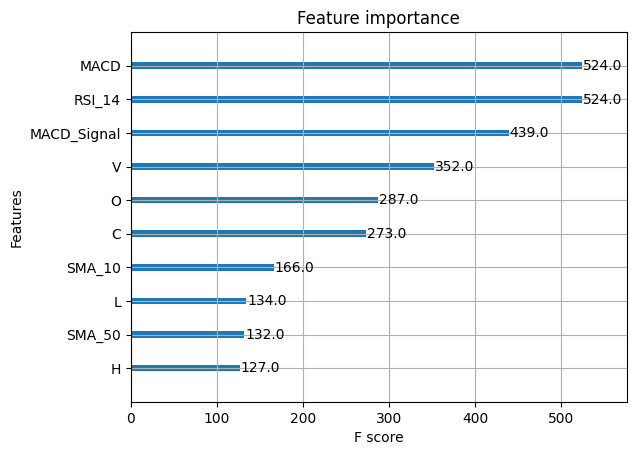

In [73]:
df["Ticker"]=df["Ticker"].astype("category")
X = df[["O", "H", "L", "C", "V", "SMA_10", "SMA_50", "RSI_14", "MACD", "MACD_Signal"]]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,shuffle=False)

model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,enable_categorical=True)
model.fit(X_train, y_train,)

xgb.plot_importance(model)

In [74]:
# Prédiction
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_labels = (y_pred > 0.5).astype(int)
# Évaluation
accuracy = accuracy_score(y_test, y_pred_labels)
X_test["Prediction"] = y_pred
X_test["Prediction_hausse"] = y_pred_proba

In [75]:
accuracy

0.5598488936859147

In [76]:
initial_cash = 10000

simulation fifo ALL-In

cash:2.575321912778234, trade:1259,portefeuille:12063.073514223111
rentabilité:20.630735142231117%
Rentabilité annuelle estimée : 0.5982508210832063%


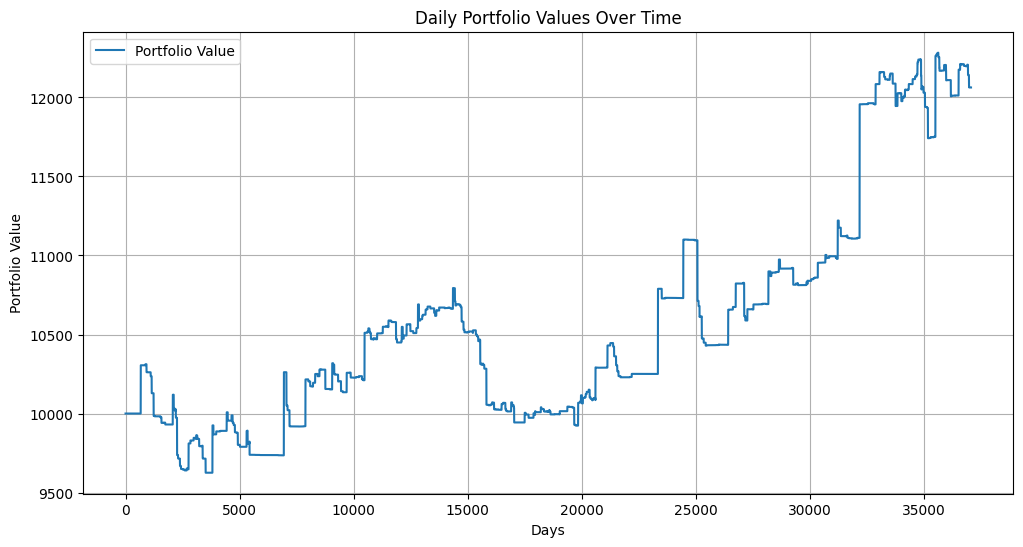

In [77]:
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée
for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    if row["Prediction"] == 1 and cash > price and ticker not in positions:
        # Buy
        positions[ticker] = (price, cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()


Simulation Fifo ALL-In stop loss

cash: 2.6117610931560176, trade: 1233, portefeuille: 12529.429945468919
rentabilité: 25.294299454689188%
Rentabilité annuelle estimée : 0.7572286709600746%


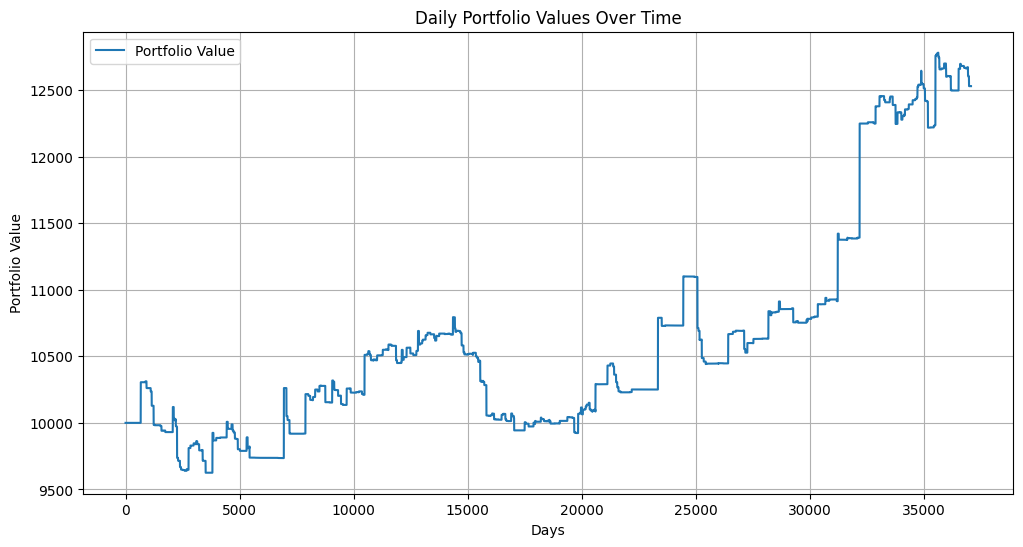

In [78]:
# Simulation parameters
trade = 0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, quantité)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

# Paramètres Stop Loss et Take Profit
stop_loss_pct = 0.03  # 3% de perte max avant vente forcée
take_profit_pct = 10  # 5% de gain avant prise de profit

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    
    # Achat
    if row["Prediction"] == 1 and cash > price and ticker not in positions:
        positions[ticker] = (price, cash // price)  # Enregistre prix d'achat et quantité
        cash -= price * positions[ticker][1]
        trade += 1
        
    # Vente conditionnelle
    elif ticker in positions:
        buy_price, quantity = positions[ticker]
        
        # Vérification du Stop Loss
        if price <= buy_price * (1 - stop_loss_pct):  # Stop Loss atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vérification du Take Profit
        elif price >= buy_price * (1 + take_profit_pct):  # Take Profit atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vente standard si prédiction négative
        elif row["Prediction"] == 0:
            cash += price * quantity
            positions.pop(ticker)
    
    daily_portfolio_values.append(cash + sum([a * b for a, b in positions.values()]))

print(f"cash: {cash}, trade: {trade}, portefeuille: {daily_portfolio_values[-1]}")
print(f"rentabilité: {(daily_portfolio_values[-1] - initial_cash) / initial_cash * 100}%")

print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()


Simulation fifo ALL-IN TP/SL

cash: 1.093305587784016, trade: 1326, portefeuille: 11329.979220390334
rentabilité: 13.299792203903344%
Rentabilité annuelle estimée : 0.36638404870168495%


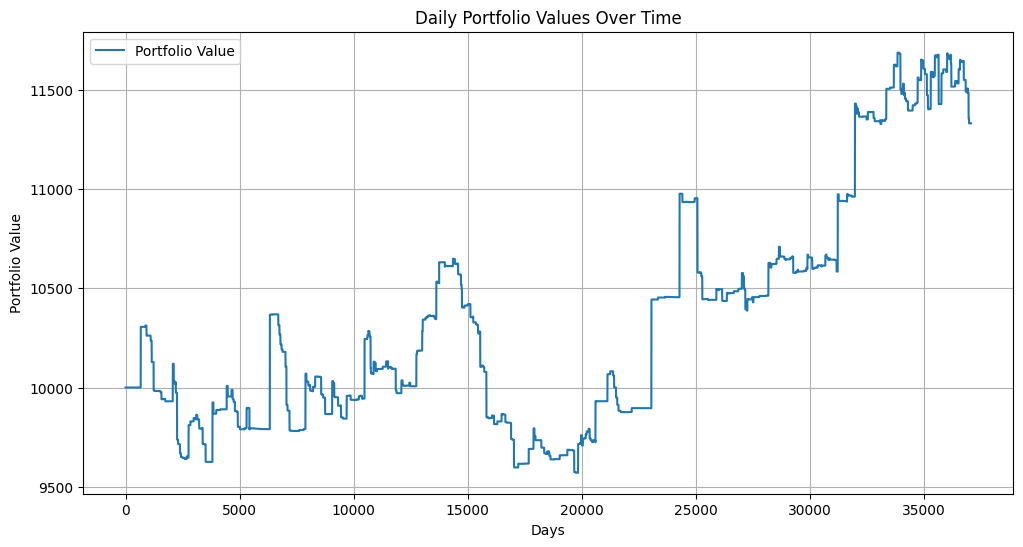

In [79]:
# Simulation parameters
trade = 0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, quantité)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

# Paramètres Stop Loss et Take Profit
stop_loss_pct = 0.03  # 3% de perte max avant vente forcée
take_profit_pct = 0.05  # 5% de gain avant prise de profit

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    
    # Achat
    if row["Prediction"] == 1 and cash > price and ticker not in positions:
        positions[ticker] = (price, cash // price)  # Enregistre prix d'achat et quantité
        cash -= price * positions[ticker][1]
        trade += 1
        
    # Vente conditionnelle
    elif ticker in positions:
        buy_price, quantity = positions[ticker]
        
        # Vérification du Stop Loss
        if price <= buy_price * (1 - stop_loss_pct):  # Stop Loss atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vérification du Take Profit
        elif price >= buy_price * (1 + take_profit_pct):  # Take Profit atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vente standard si prédiction négative
        elif row["Prediction"] == 0:
            cash += price * quantity
            positions.pop(ticker)
    
    daily_portfolio_values.append(cash + sum([a * b for a, b in positions.values()]))

print(f"cash: {cash}, trade: {trade}, portefeuille: {daily_portfolio_values[-1]}")
print(f"rentabilité: {(daily_portfolio_values[-1] - initial_cash) / initial_cash * 100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()


Simulation fraction mobile

cash:271.10603976249695, trade:4247,portefeuille:10998.569270849228
rentabilité:9.985692708492278%
Rentabilité annuelle estimée : 0.26864609215634516%


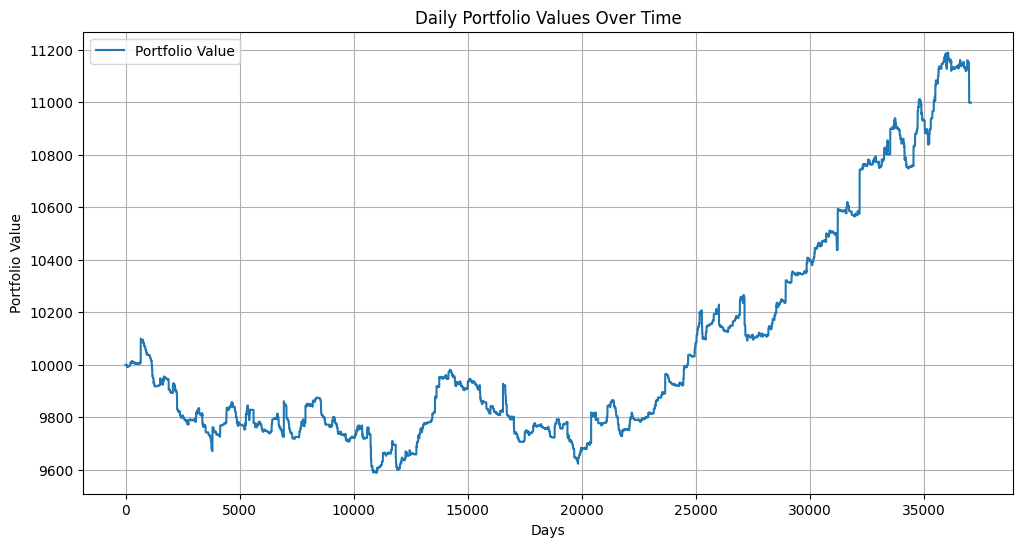

In [80]:
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

fraction=0.3

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    max_cash = fraction * cash
    if row["Prediction"] == 1 and max_cash > price and ticker not in positions:
        # Buy
        positions[ticker] = (price, max_cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

Simulaton Fraction fixe

cash:-33436.602435112, trade:4670,portefeuille:13877.492804527283
rentabilité:38.77492804527283%
Rentabilité annuelle estimée : 1.268702382139217%


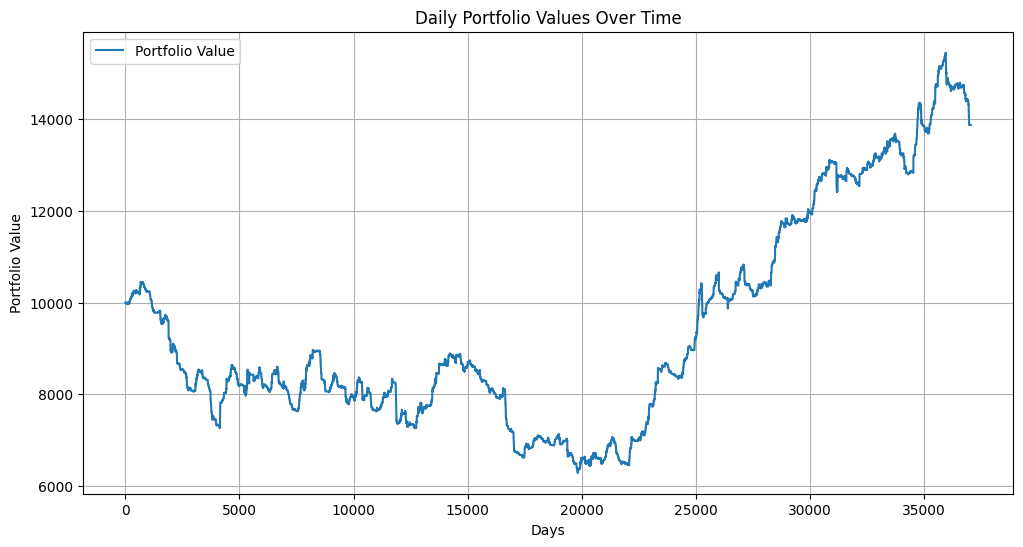

In [81]:
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

fraction=0.3
max_cash = fraction * initial_cash
for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]

    if row["Prediction"] == 1 and max_cash > price and ticker not in positions:
        # Buy
        positions[ticker] = (price, max_cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

Simulation risque fixe

cash: 1.3058912754131526, trade: 1778, portefeuille: 10960.509163618095
rentabilité: 9.60509163618095%
Rentabilité annuelle estimée : 0.2576993131477707%


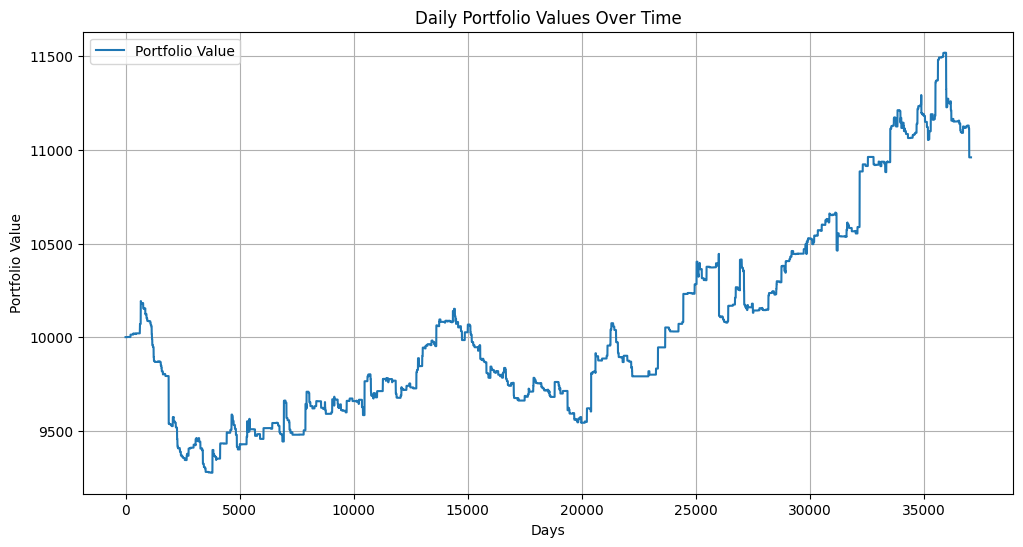

In [82]:
# Simulation parameters
trade = 0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, quantité)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

fixed_risk=0.02
# Paramètres Stop Loss et Take Profit
stop_loss_pct = 0.05  # 3% de perte max avant vente forcée
take_profit_pct = 10  # 5% de gain avant prise de profit

max_investment = initial_cash * fixed_risk/stop_loss_pct

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    
    # Achat
    if row["Prediction"] == 1 and cash > price and ticker not in positions:
        if cash>max_investment:
            positions[ticker] = (price, max_investment // price)
        else:positions[ticker] = (price, cash // price)  # Enregistre prix d'achat et quantité
        cash -= price * positions[ticker][1]
        trade += 1
        
    # Vente conditionnelle
    elif ticker in positions:
        buy_price, quantity = positions[ticker]
        
        # Vérification du Stop Loss
        if price <= buy_price * (1 - stop_loss_pct):  # Stop Loss atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vérification du Take Profit
        elif price >= buy_price * (1 + take_profit_pct):  # Take Profit atteint
            cash += price * quantity
            positions.pop(ticker)
        
        # Vente standard si prédiction négative
        elif row["Prediction"] == 0:
            cash += price * quantity
            positions.pop(ticker)
    
    daily_portfolio_values.append(cash + sum([a * b for a, b in positions.values()]))

print(f"cash: {cash}, trade: {trade}, portefeuille: {daily_portfolio_values[-1]}")
print(f"rentabilité: {(daily_portfolio_values[-1] - initial_cash) / initial_cash * 100}%")

print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()


Simulation Kelly Criterion

cash:6020.088634490967, trade:3688,portefeuille:10281.913671016693
rentabilité:2.819136710166931%
Rentabilité annuelle estimée : 0.0719755571163383%


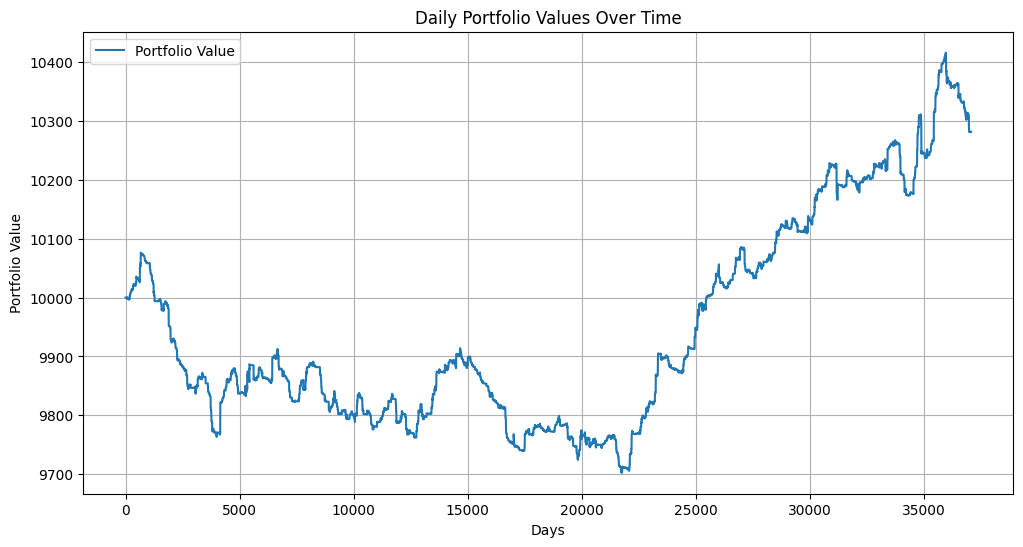

In [83]:
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

ratio_profit_perte=2

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    max_cash = (2 * row["Prediction_hausse"]-1)/ratio_profit_perte * cash
    if row["Prediction"] == 1 and max_cash > price and ticker not in positions:
        # Buy
        positions[ticker] = (price, max_cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

Simulation investissement dynamique basé sur le marché

cash:9090.87056016922, trade:1116,portefeuille:10114.527567386627
rentabilité:1.145275673866272%
Rentabilité annuelle estimée : 0.028878296186163777%


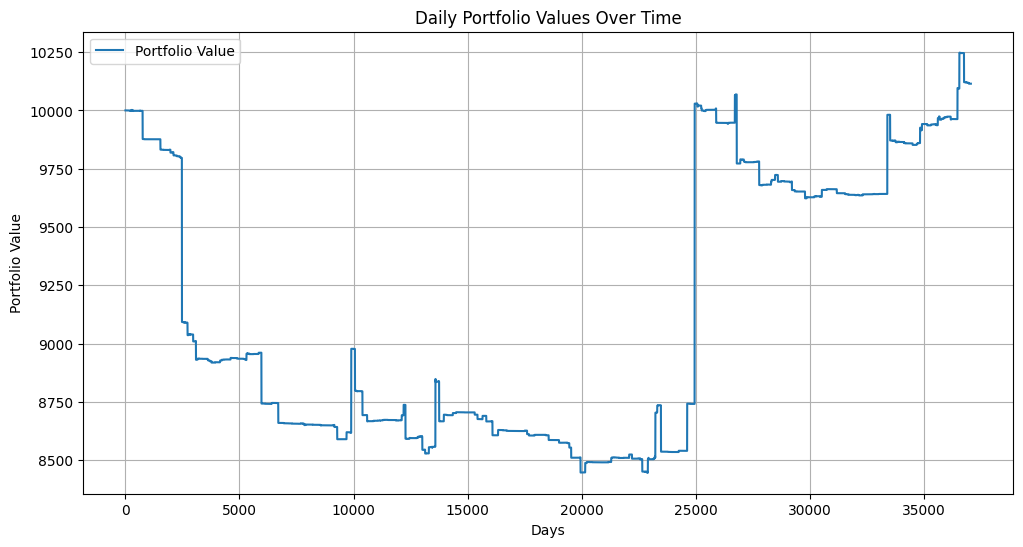

In [84]:
df_wide["ROC_10"] = df_wide.groupby("Ticker")["C"].transform(lambda x: ta.momentum.ROCIndicator(x, window=10).roc())
scaler = MinMaxScaler()
# Calcul de la somme des momentums (ROC_10) par Ticker
df_wide["ROC_10_sum"] = df_wide.groupby("Ticker")["ROC_10"].transform("sum")
# Normalisation en divisant chaque momentum par la somme des momentums pour chaque Ticker
df_wide["ROC_10_normalized"] = df_wide["ROC_10"] / df_wide["ROC_10_sum"]

# Optionnel : Supprimer la colonne temporaire "ROC_10_sum" si tu n'en as plus besoin
df_wide.drop(columns=["ROC_10_sum"], inplace=True)

# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée

ratio_profit_perte=2

for i in range(len(X_test)):
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]
    max_cash =df_wide.iloc[len(df_wide)-len(X_test)-2+i]["ROC_10_normalized"] * cash
    if row["Prediction"] == 1 and max_cash > price and ticker not in positions:
        # Buy
        positions[ticker] = (price, max_cash//price)
        cash = cash- price*positions[ticker][1]
        trade+=1
        #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

Simulation Livio

In [85]:
df_wide.head()

,Datetime,Ticker,C,H,L,O,V,ROC_10,ROC_10_normalized
0,2023-03-14 08:00:00+00:00,AC.PA,29.330000,29.330000,28.990000,29.049999,0.0,NaN,NaN
1,2023-03-14 08:00:00+00:00,ACA.PA,10.588000,10.690000,10.514000,10.634000,0.0,NaN,NaN
2,2023-03-14 08:00:00+00:00,AI.PA,133.690903,134.000000,133.072739,133.563629,0.0,NaN,NaN
3,2023-03-14 08:00:00+00:00,AIR.PA,119.599998,119.720001,118.160004,118.160004,0.0,NaN,NaN
4,2023-03-14 08:00:00+00:00,BN.PA,54.299999,54.450001,54.020000,54.330002,0.0,NaN,NaN


cash:1.5665116310117355, trade:4669,portefeuille:11180.461985111237
rentabilité:11.804619851112367%
Rentabilité annuelle estimée : 0.3217501648438579%


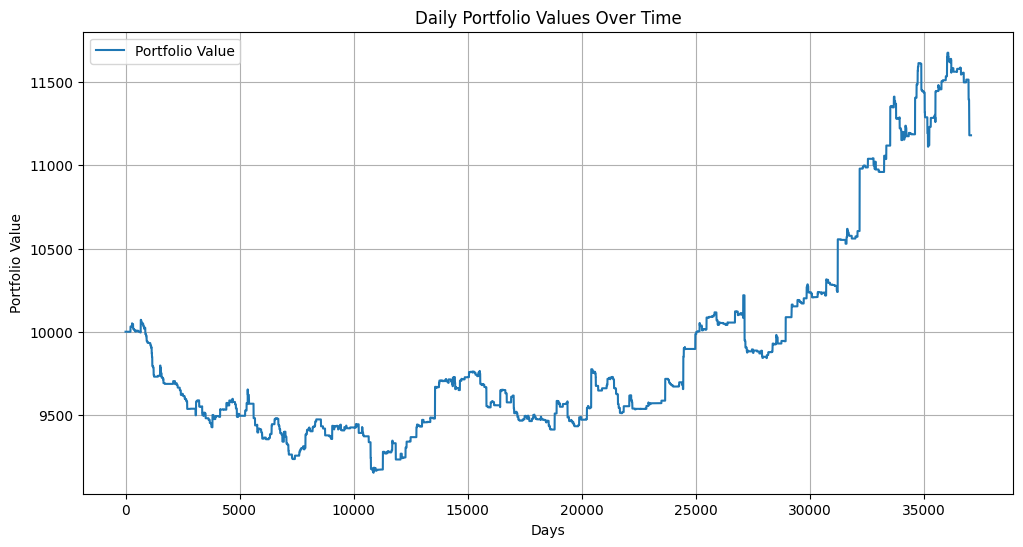

In [117]:
# Simulation parameters
trade=0
cash = initial_cash
positions = {}  # Stocke les positions ouvertes {ticker: (achat_prix, achat_date)}
daily_portfolio_values = []  # Stocke la valeur du portefeuille à la fin de chaque journée
w_history=[]

fraction=0.5
window_size=1000
fract_max_cash = fraction * initial_cash
for i in range(len(X_test)):

    w=[]
    row = X_test.iloc[i]
    ticker = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["Ticker"]
    price = df_wide.iloc[len(df_wide)-len(X_test)-2+i]["C"]

    if row["Prediction"] == 1:
        if not positions and 0.25*cash > price:
            # Buy
            positions[ticker] = (price, 0.25*cash//price)
            cash = cash- price*positions[ticker][1]
            trade+=1
            #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")
        elif ticker not in positions:
            corr_tickers=list(positions.keys())
            
            df_filtered = df_wide[df_wide['Ticker'].isin(corr_tickers+[ticker])].loc[len(df_wide)-len(X_test)-2+i-window_size:len(df_wide)-len(X_test)-2+i]
            # Pivot le DataFrame pour que chaque ticker ait sa propre colonne de prix de clôture 'C'
            df_pivoted = df_filtered.pivot(index='Datetime', columns='Ticker', values='C')
            # Calcul de la corrélation entre les tickers
            correlation_matrix = df_pivoted.corr()
            for j in corr_tickers:
                correlation = correlation_matrix.loc[ticker, j]
                w.append(correlation)  
            mean_w=np.mean(w)** 2
            w=1-mean_w
            w_history.append(w)
            max_cash = w * fract_max_cash
            max_cash = max(0, max_cash)
            if max_cash > price:
                if cash>max_cash:
                    positions[ticker] = (price, max_cash // price)
                else:
                    positions[ticker] = (price, cash//price)
                cash = cash- price*positions[ticker][1]
                trade+=1
                #print(f"trade n°{trade}:Achat de {positions[ticker][1]} actions à {price} pour {ticker}")   
        
    elif row["Prediction"] == 0 and ticker in positions:
        # Sell
        cash += price*positions[ticker][1]
        #print(f"Vente de {positions[ticker][1]} actions à {price} pour {ticker} (gain : {(cash + sum([a*b for a, b in positions.values()]))/initial_cash*100}%)")
        positions.pop(ticker)

    daily_portfolio_values.append(cash + sum([a*b for a, b in positions.values()]))
print(f"cash:{cash}, trade:{trade},portefeuille:{daily_portfolio_values[-1]}")
print(f"rentabilité:{(daily_portfolio_values[-1]-initial_cash)/initial_cash*100}%")
print(f"Rentabilité annuelle estimée : {(1 + (daily_portfolio_values[-1] - initial_cash) / initial_cash) ** (12 / 4.8) - 1}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_values, label="Portfolio Value")
plt.title("Daily Portfolio Values Over Time")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()